<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/non-markovian_black-hole_evaporation/blob/main/MvNM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy, Operator

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Architecture (revised per Subhashish Banerjee, May 2026):
#   - N_BH qubits: black hole register, starts fully occupied
#   - Radiation register: starts EMPTY, grows by 1 qubit per emission step
#   - No separate ENV register — radiation IS the environment
#   - Emitted qubits accumulate memory via collision-model inter-ancilla
#     interactions (Lorenzo, Ciccarello & Palma 2017) and back-act on BH
#   - Global statevector: fixed 2^N_BH dimension throughout (pure state)
#
# Primary observable: S_BH = von Neumann entropy of BH register
#   - Markovian: S(BH) falls due to Hilbert-space shrinking; S(R) monotonic
#   - Non-Markovian: S(BH) shows Page-curve-like recovery; S(R) peaks+falls
#
# Markovian model: numpy density matrix + depolarising Kraus channel (p=1)
#   - Qubit 0 fully decohered each step: information DESTROYED, not transferred
#   - S(radiation) = cumulative entropy emitted = monotonically increasing
#   - This is the GKSL Lindblad limit in discrete time
#
# Page time = N_BH // 2

N_BH = 10          # black hole size (14 exceeds available RAM for statevector)
C_M  = '#1A6FB5'   # Markovian colour
C_NM = '#E06000'   # Non-Markovian colour

print(f"Setup: N_BH={N_BH}, N_RAD_initial=0, Page time ≈ step {N_BH//2}")
print(f"Radiation register grows from 0 to {N_BH} qubits over evaporation.")

Setup: N_BH=10, N_RAD_initial=0, Page time ≈ step 5
Radiation register grows from 0 to 10 qubits over evaporation.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCUIT BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

def scramble_black_hole(qc, bh):
    """
    Fast-scrambler dynamics on BH register.
    Random layered two-qubit gates implement approximate Haar-random unitary
    (unitary k-design at polynomial depth; Harrow & Low 2009, Brandao et al 2016).
    Models the black hole's own chaotic Hamiltonian evolution.
    Black holes are conjectured to be fastest scramblers in nature (Sekino &
    Susskind 2008): t* ~ log(N_BH).
    """
    LAYERS = 2
    for _ in range(LAYERS):
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)
        if len(bh) > 1:
            for i in range(len(bh) - 1):
                qc.cx(bh[i], bh[i+1])
                qc.cz(bh[i], bh[i+1])
            for i in range(0, len(bh)-1, 2):
                qc.swap(bh[i], bh[i+1])
            if len(bh) > 3:
                qc.cx(bh[0], bh[-1])
                qc.cy(bh[1], bh[-2])


def radiation_memory_interaction(qc, rad):
    """
    Collision-model inter-ancilla interaction on radiation register.
    Previously emitted qubits interact with each other, building correlations
    in the radiation — this IS the non-Markovian memory mechanism.
    Implements the sum_k J_kn V_{A_k, A_n} term from the composite collision
    model (Lorenzo, Ciccarello & Palma 2017, Phys Rev A 96, 032107).
    """
    if len(rad) < 2:
        return
    for i in range(len(rad) - 1):
        qc.cx(rad[i], rad[i+1])
        qc.cz(rad[i+1], rad[i])
        qc.rx(np.random.uniform(0, 2*np.pi), rad[i])
        qc.ry(np.random.uniform(0, 2*np.pi), rad[i+1])
        qc.rz(np.random.uniform(0, 2*np.pi), rad[i])


def bh_radiation_backaction(qc, bh, rad):
    """
    BH-radiation back-action: accumulated radiation state feeds back into BH.
    This is the non-Markovian memory channel — information previously lost to
    radiation partially returns to the BH system. Violates CP-divisibility.
    """
    angle = np.pi/4
    for b in bh:
        for i, r in enumerate(rad):
            coupling = angle * np.exp(-0.3 * (len(rad) - 1 - i))
            qc.cz(b, r)          # Z-type: dephasing
            qc.cx(r, b)          # X-type: bit-flip back-action
            qc.rx(coupling, b)
            qc.ry(coupling, r)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# KRYLOV SPREAD COMPLEXITY
# Trajectory-based Gram-Schmidt adaptation (no Hamiltonian)
# ─────────────────────────────────────────────────────────────────────────────
_krylov_basis = []

def _reset_krylov():
    global _krylov_basis
    _krylov_basis = []

def compute_spread_complexity(state_history):
    """
    Circuit-native Krylov spread complexity.
    Standard spread complexity (Balasubramanian et al 2022) requires a
    Hamiltonian to generate the Krylov basis via Lanczos recursion.
    Since this model is purely gate-based (no explicit Hamiltonian), we adapt:
    the Krylov basis {|b_n>} is built by incremental Gram-Schmidt
    orthogonalisation of the evolved statevector trajectory {|psi(t)>}.
    Spread complexity: K(t) = sum_n n |<b_n|psi(t)>|^2.
    Global statevector is fixed dimension 2^N_BH throughout — inner products
    are always well-defined.
    """
    global _krylov_basis
    for state in state_history[len(_krylov_basis):]:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        for b in _krylov_basis:
            vec -= np.vdot(b, vec) * b
        norm = np.linalg.norm(vec)
        if norm > 1e-10:
            _krylov_basis.append(vec / norm)
    complexities = []
    for state in state_history:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        k_t = sum(n * abs(np.vdot(b, vec))**2
                  for n, b in enumerate(_krylov_basis))
        complexities.append(k_t)
    return complexities

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# MARKOVIAN EVAPORATION — DEPOLARISING KRAUS CHANNEL
# ─────────────────────────────────────────────────────────────────────────────
# Physical content of Markovianity:
#   At each step, BH qubit 0 is subjected to a fully depolarising channel
#   (p=1). Kraus operators: {I/2, X/2, Y/2, Z/2}. Net effect: qubit 0
#   is decohered to the maximally mixed state I/2, all entanglement with
#   it destroyed. Information is DESTROYED, not transferred. This is the
#   GKSL Lindblad limit in discrete time — a memoryless, CP-divisible map.
#
#   After Kraus: trace out qubit 0 (BH shrinks). No back-action possible
#   because the channel is product at every step (fresh bath per emission).
#
#   Observable: S(BH) falls due to Hilbert-space shrinking (dimension halves
#   at each step — inevitable, not a Page curve). S(R_cumulative) = sum of
#   entropy emitted per step = monotonically increases to N_BH bits.
#   This monotonic S(R) is the Markovian signature.
# ─────────────────────────────────────────────────────────────────────────────

def vn_entropy_np(rho, base=2):
    ev = np.linalg.eigvalsh(rho)
    ev = ev[ev > 1e-12]
    return float(-np.sum(ev * np.log2(ev))) if base == 2 else float(-np.sum(ev * np.log(ev)))

def partial_trace_qubit0_np(rho, n_qubits):
    """Trace out qubit 0 from n_qubit numpy density matrix."""
    h = 2**(n_qubits - 1)
    return rho[:h, :h] + rho[h:, h:]

def run_markovian_evaporation():
    """
    Markovian BH evaporation.
    State: numpy density matrix (avoids 2^N x 2^N Qiskit DensityMatrix allocation).
    Scramble unitary obtained from Qiskit Operator on shrinking BH circuit.
    Depolarising Kraus (p=1) applied to qubit 0 each step.
    Tracks: S(BH), S(R_emitted_per_step), S(R_cumulative).
    """
    print("Starting Markovian Evaporation (depolarising Kraus, p=1)...")
    ent_bh, ent_rad_cumul, steps = [], [], []
    n_bh = N_BH
    rho = np.zeros((2**n_bh, 2**n_bh), dtype=complex)
    rho[0, 0] = 1.0   # |0...0><0...0|
    S_rad_total = 0.0

    I2 = np.eye(2, dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)
    paulis = [I2, X, Y, Z]

    for step in range(1, N_BH + 1):
        if n_bh == 0:
            break

        # 1. Scramble BH
        qc = QuantumCircuit(n_bh)
        scramble_black_hole(qc, list(range(n_bh)))
        U = Operator(qc).data
        rho = U @ rho @ U.conj().T

        # 2. Depolarising Kraus on qubit 0 (p=1, full decoherence)
        I_rest = np.eye(2**(n_bh-1), dtype=complex)
        kraus  = [np.kron(P, I_rest) / np.sqrt(4) for P in paulis]
        rho    = sum(K @ rho @ K.conj().T for K in kraus)

        # 3. Entropy of qubit 0 (emitted this step) before tracing out
        rho_reshaped = rho.reshape(2, 2**(n_bh-1), 2, 2**(n_bh-1))
        rho_q0 = np.einsum('iaja->ij', rho_reshaped)
        S_emitted = vn_entropy_np(rho_q0)
        S_rad_total += S_emitted

        # 4. Trace out qubit 0 — BH shrinks
        rho  = partial_trace_qubit0_np(rho, n_bh)
        n_bh -= 1

        S_BH = vn_entropy_np(rho) if n_bh > 0 else 0.0
        ent_bh.append(S_BH)
        ent_rad_cumul.append(S_rad_total)
        steps.append(step)

        print(f"[Markovian]     Step {step:2d}/{N_BH} | "
              f"S(BH)={S_BH:.4f} | S(R_cumul)={S_rad_total:.4f}")

    return steps, ent_bh, ent_rad_cumul

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-MARKOVIAN EVAPORATION — COLLISION MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Architecture:
#   Global pure statevector: fixed N_BH qubits throughout.
#   BH register [0..n_bh-1]: shrinks by 1 each step.
#   Radiation register [n_bh..N_BH-1]: grows by 1 each step.
#   Radiation = Environment: emitted qubits retained, inter-ancilla memory
#   interactions implemented (composite collision model, Lorenzo et al 2017).
#   Back-action: accumulated radiation feeds back into remaining BH —
#   this violates CP-divisibility => non-Markovian dynamical map.
#
# Primary observable: S_BH = vN entropy of BH register (Page curve quantity).
#   By purity of global state: S(BH) = S(R) at all times.
#   I(R:BH) = S(R) + S(BH) - S(RuBH) = S(R) + S(BH) [since S(RuBH)=0].
#   => I(R:BH) = 2*S(BH) exactly (verified below).
# ─────────────────────────────────────────────────────────────────────────────

def run_non_markovian_evaporation():
    _reset_krylov()
    print("Starting Non-Markovian Evaporation (collision model)...")

    current_state = Statevector.from_label('0' * N_BH)
    bh  = list(range(N_BH))
    rad = []
    ent_bh, ent_rad, mi, steps, state_history = [], [], [], [], []

    for step in range(1, N_BH + 1):
        # Build gate circuit (fixed N_BH-qubit Hilbert space)
        step_qc = QuantumCircuit(N_BH)



        # 1. Scramble BH register
        if len(bh) > 0:
            scramble_black_hole(step_qc, bh)

       # 2. Radiation memory: inter-ancilla collision model interactions
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)

        # 3. BH-radiation back-action (non-Markovian memory channel)
        if len(bh) > 0 and len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad)


        # Evolve global statevector
        current_state = current_state.evolve(step_qc)
        state_history.append(current_state)

        # Emit: transfer bh[0] to radiation register
        emitted = bh.pop(0)
        rad.append(emitted)

        # Measure S(BH): trace out radiation
        if len(bh) > 0:
            rho_BH = partial_trace(current_state, rad)
            S_BH   = entropy(rho_BH, base=2)
            rho_R  = partial_trace(current_state, bh)
            S_R    = entropy(rho_R, base=2)
            # Pure global state: S(RuBH)=0 => I(R:BH) = S(R)+S(BH)
            I_RBH  = S_R + S_BH
        else:
            S_BH = S_R = I_RBH = 0.0

        ent_bh.append(S_BH)
        ent_rad.append(S_R)
        mi.append(I_RBH)
        steps.append(step)

        current_K = compute_spread_complexity(state_history)[-1]
        print(f"[Non-Markovian] Step {step:2d}/{N_BH} | "
              f"S(BH)={S_BH:.4f} | S(R)={S_R:.4f} | "
              f"K(t)={current_K:.4f} | I(R:BH)={I_RBH:.4f}")

    return steps, ent_bh, ent_rad, mi, state_history

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
s_m,  ebh_m,  erad_m                          = run_markovian_evaporation()
s_nm, ebh_nm, erad_nm, mi_nm, states_nm       = run_non_markovian_evaporation()

dS_bh_m  = np.diff(ebh_m)
dS_bh_nm = np.diff(ebh_nm)

_reset_krylov()
k_nm = compute_spread_complexity(states_nm)

page_idx  = np.argmax(mi_nm)
page_step = s_nm[page_idx]
print(f"\nPage time (peak I(R:BH)): step {page_step}")

Starting Markovian Evaporation (depolarising Kraus, p=1)...
[Markovian]     Step  1/10 | S(BH)=0.9968 | S(R_cumul)=1.0000
[Markovian]     Step  2/10 | S(BH)=1.9877 | S(R_cumul)=2.0000
[Markovian]     Step  3/10 | S(BH)=2.9491 | S(R_cumul)=3.0000
[Markovian]     Step  4/10 | S(BH)=3.8090 | S(R_cumul)=4.0000
[Markovian]     Step  5/10 | S(BH)=4.2767 | S(R_cumul)=5.0000
[Markovian]     Step  6/10 | S(BH)=3.8180 | S(R_cumul)=6.0000
[Markovian]     Step  7/10 | S(BH)=2.9478 | S(R_cumul)=7.0000
[Markovian]     Step  8/10 | S(BH)=1.9889 | S(R_cumul)=8.0000
[Markovian]     Step  9/10 | S(BH)=0.9961 | S(R_cumul)=9.0000
[Markovian]     Step 10/10 | S(BH)=0.0000 | S(R_cumul)=10.0000
Starting Non-Markovian Evaporation (collision model)...
[Non-Markovian] Step  1/10 | S(BH)=0.9903 | S(R)=0.9903 | K(t)=0.0000 | I(R:BH)=1.9807
[Non-Markovian] Step  2/10 | S(BH)=1.9820 | S(R)=1.9820 | K(t)=0.9995 | I(R:BH)=3.9640
[Non-Markovian] Step  3/10 | S(BH)=2.9614 | S(R)=2.9614 | K(t)=1.9984 | I(R:BH)=5.9228
[N

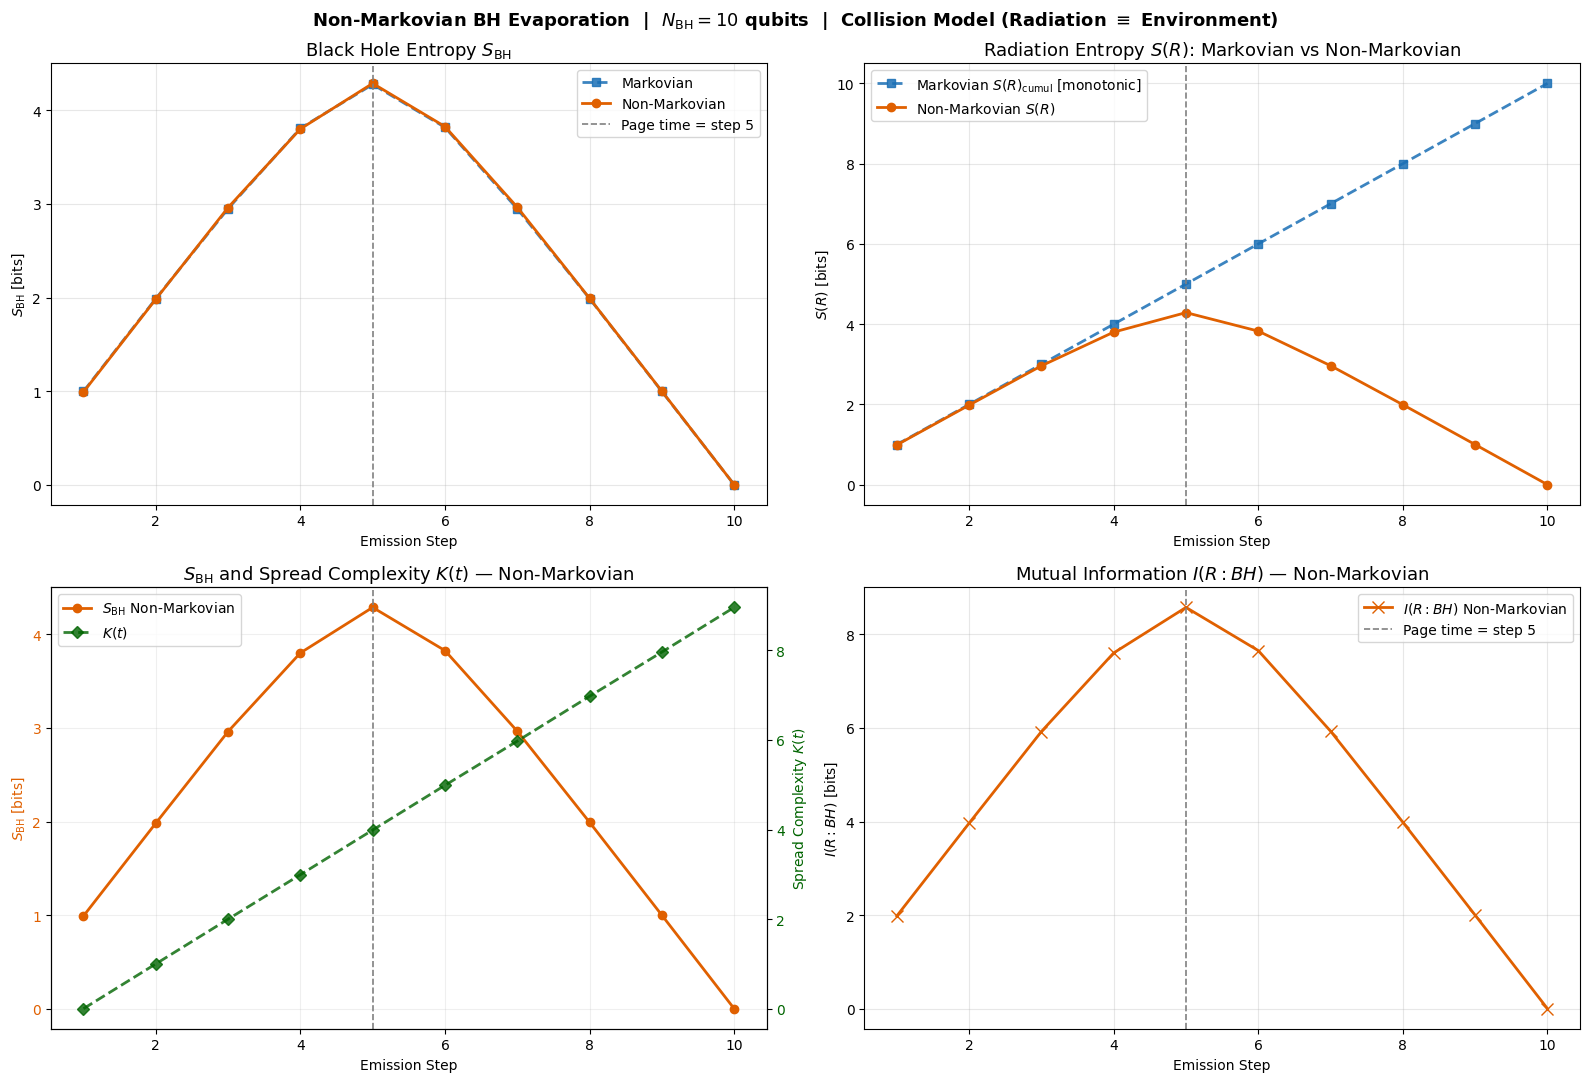

Saved: evaporation_results.pdf


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Plot 1: S(BH) — Markovian vs Non-Markovian ───────────────────────────────
ax = axes[0, 0]
ax.plot(s_m,  ebh_m,  's--', color=C_M,  lw=2, alpha=0.85, label='Markovian')
ax.plot(s_nm, ebh_nm, 'o-',  color=C_NM, lw=2,             label='Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time = step {page_step}')
ax.set_title(r'Black Hole Entropy $S_{\rm BH}$', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$S_{\rm BH}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── Plot 2: S(R) — Markovian S(R_cumul) monotonic vs NM S(R) Page-curve ─────
ax = axes[0, 1]
ax.plot(s_m,  erad_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian $S(R)_{\rm cumul}$ [monotonic]')
ax.plot(s_nm, erad_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian $S(R)$')
ax.axvline(page_step, color='gray', ls='--', lw=1.2)
ax.set_title(r'Radiation Entropy $S(R)$: Markovian vs Non-Markovian', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$S(R)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── Plot 3: S(BH) and K(t) — Non-Markovian, dual axis ────────────────────────
ax_s = axes[1, 0]
ax_k = ax_s.twinx()
l1, = ax_s.plot(s_nm, ebh_nm, 'o-',  color=C_NM,       lw=2,
                label=r'$S_{\rm BH}$ Non-Markovian')
l2, = ax_k.plot(s_nm, k_nm,   'D--', color='darkgreen', lw=2, alpha=0.8,
                label=r'$K(t)$')
ax_s.axvline(page_step, color='gray', ls='--', lw=1.2)
ax_s.set_ylabel(r'$S_{\rm BH}$ [bits]', color=C_NM)
ax_s.tick_params(axis='y', labelcolor=C_NM)
ax_k.set_ylabel(r'Spread Complexity $K(t)$', color='darkgreen')
ax_k.tick_params(axis='y', labelcolor='darkgreen')
ax_s.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax_s.set_title(r'$S_{\rm BH}$ and Spread Complexity $K(t)$ — Non-Markovian', fontsize=13)
ax_s.set_xlabel('Emission Step'); ax_s.grid(alpha=0.2)

# ── Plot 4: Mutual Information I(R:BH) — Non-Markovian ───────────────────────
ax = axes[1, 1]
ax.plot(s_nm, mi_nm, 'x-', color=C_NM, lw=2, markersize=8,
        label=r'$I(R{:}BH)$ Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time = step {page_step}')
ax.set_title(r'Mutual Information $I(R{:}BH)$ — Non-Markovian', fontsize=13)
ax.set_xlabel('Emission Step'); ax.set_ylabel(r'$I(R{:}BH)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle(
    f'Non-Markovian BH Evaporation  |  $N_{{\\rm BH}}={N_BH}$ qubits  |  '
    r'Collision Model (Radiation $\equiv$ Environment)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('evaporation_results.pdf', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: evaporation_results.pdf')

## BLP Non-Markovianity Measure

**Protocol (Breuer, Laine & Piilo 2009):**
1. Prepare two initial BH states:  
   - Probe 1: $|0\rangle^{\otimes N_{\rm BH}}$  
   - Probe 2: $|{+}\rangle|0\rangle^{\otimes (N_{\rm BH}-1)}$
2. Evolve both through identical NM circuit (fixed random seed — isolates memory from randomness)
3. At each step: partial-trace radiation register → reduced BH state $\rho_{\rm BH}(t)$
4. Compute trace distance $D(t) = \frac{1}{2}\|\rho_1(t) - \rho_2(t)\|_1$
5. BLP measure: $\mathcal{N}_{\rm BLP} = \sum_{\Delta D > 0} \Delta D(t)$

$\mathcal{N}_{\rm BLP} > 0$ $\Leftrightarrow$ information backflow $\Leftrightarrow$ non-Markovian dynamics.

Computing BLP measure  (N_BH=12)...
Probe 1: |0>^{N_BH}
Probe 2: |+>|0>^{N_BH-1}
Both probes: seed=42 — identical gate angles isolate memory effects.

Trace distances D(t):
  Step  1: D = 0.664918
  Step  2: D = 0.705913
  Step  3: D = 0.702317
  Step  4: D = 0.684072
  Step  5: D = 0.619256
  Step  6: D = 0.402483
  Step  7: D = 0.208222
  Step  8: D = 0.101549
  Step  9: D = 0.049216
  Step 10: D = 0.026976
  Step 11: D = 0.014343
  Step 12: D = 0.007955

BLP measure  N_BLP = 0.040995
→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).
  Trace-distance revivals confirm information backflow from radiation to BH.


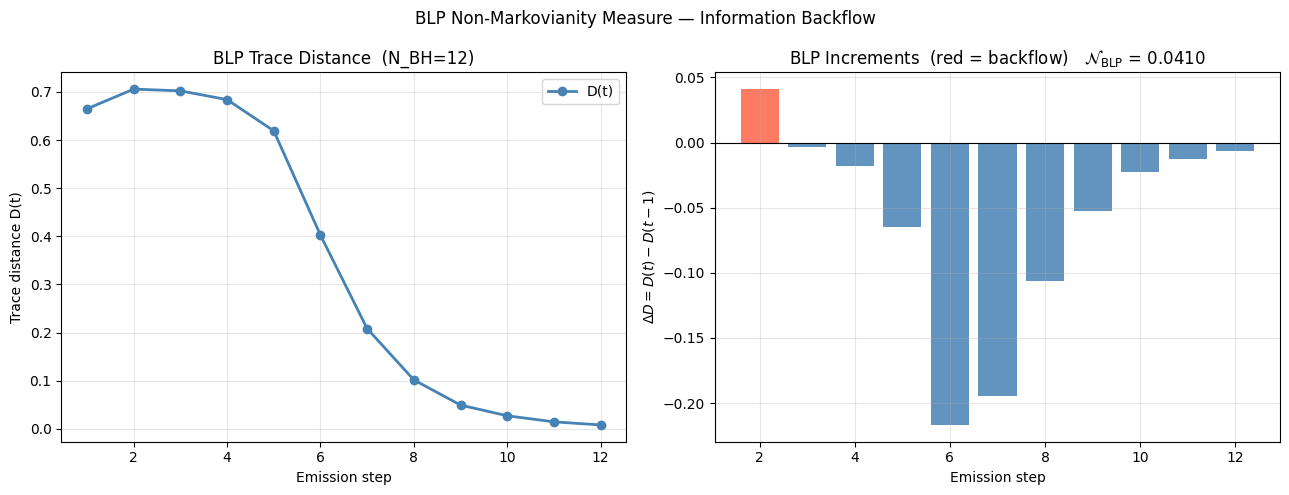

Saved: blp_measure.pdf


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP NON-MARKOVIANITY MEASURE
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
# ─────────────────────────────────────────────────────────────────────────────
N_BH = 12
def trace_distance(rho1, rho2) -> float:
    """D(rho1, rho2) = (1/2) Tr|rho1 - rho2| via eigenvalue decomposition."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))


def run_evaporation_for_blp(probe: str, seed: int = 42):
    """
    Non-Markovian evaporation for BLP computation.
    Returns reduced BH density matrix rho_BH(t) at each step,
    obtained by partial-tracing the global statevector over the
    radiation register.

    probe : 'zero' -> |0...0>^N_BH
            'plus' -> |+>|0>^(N_BH-1)
    seed  : fixed so both probes see identical random gate angles —
            any difference in D(t) is due to initial condition alone,
            not circuit randomness. This isolates the memory effect.
    """
    np.random.seed(seed)

    init_label = ('+' + '0' * (N_BH - 1)) if probe == 'plus' else ('0' * N_BH)
    state = Statevector.from_label(init_label)

    bh  = list(range(N_BH))
    rad = []
    rho_series = []

    while len(bh) > 0:
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad)

        state = state.evolve(step_qc)

       # Reduced BH interior state: trace out radiation + boundary qubit
        trace_out = rad + ([bh[0]] if len(bh) > 1 else [])
        if trace_out:
            rho_interior = partial_trace(state, trace_out)
        else:
            # step 1, rad=[], only 1 BH qubit — just use full BH state
            rho_interior = partial_trace(state, [])
        rho_series.append(rho_interior)
        emitted = bh.pop(0)
        rad.append(emitted)

    return rho_series


print(f"Computing BLP measure  (N_BH={N_BH})...")
print(f"Probe 1: |0>^{{N_BH}}")
print(f"Probe 2: |+>|0>^{{N_BH-1}}")
print("Both probes: seed=42 — identical gate angles isolate memory effects.\n")

rho_series_1 = run_evaporation_for_blp('zero', seed=42)
rho_series_2 = run_evaporation_for_blp('plus', seed=42)

T         = min(len(rho_series_1), len(rho_series_2))
D_values  = [trace_distance(rho_series_1[t], rho_series_2[t]) for t in range(T)]
steps_blp = list(range(1, T + 1))
dD        = np.diff(D_values)
N_BLP     = float(np.sum(dD[dD > 0]))

print("Trace distances D(t):")
for t, d in zip(steps_blp, D_values):
    print(f"  Step {t:2d}: D = {d:.6f}")
print(f"\nBLP measure  N_BLP = {N_BLP:.6f}")
if N_BLP > 1e-6:
    print("→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).")
    print("  Trace-distance revivals confirm information backflow from radiation to BH.")
else:
    print("→ N_BLP ≈ 0 — no detectable backflow.")

# ── BLP plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(steps_blp, D_values, 'o-', color='steelblue', lw=2, label='D(t)')
axes[0].set_xlabel("Emission step")
axes[0].set_ylabel("Trace distance D(t)")
axes[0].set_title(f"BLP Trace Distance  (N_BH={N_BH})")
axes[0].grid(alpha=0.3); axes[0].legend()

bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
axes[1].bar(steps_blp[1:], dD, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel("Emission step")
axes[1].set_ylabel(r"$\Delta D = D(t) - D(t-1)$")
axes[1].set_title(
    f"BLP Increments  (red = backflow)   "
    r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
)
axes[1].grid(alpha=0.3)

plt.suptitle("BLP Non-Markovianity Measure — Information Backflow", fontsize=12)
plt.tight_layout()
plt.savefig("blp_measure.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_measure.pdf")